# CICDDoS2019 DDoS Detection using Logistic Regression, LSTM and Autoencoder

Run this notebook in **Google Colab with T4 GPU**. It automatically finds your `DDoS_LSTM_Autoencoder_Project` folder in Google Drive, loads the cleaned CICDDoS2019 dataset, performs EDA, trains models, saves graphs/metrics, and exports model files for the website backend.

In [1]:
# Install dependencies
!pip -q install scikit-learn tensorflow joblib matplotlib pandas numpy

In [2]:
from google.colab import drive
import os, json, glob, warnings
from pathlib import Path
warnings.filterwarnings('ignore')

drive.mount('/content/drive')

# Auto-detect project root inside Google Drive
candidates = glob.glob('/content/drive/MyDrive/**/DDoS_LSTM_Autoencoder_Project', recursive=True)
if not candidates:
    raise FileNotFoundError('Could not find DDoS_LSTM_Autoencoder_Project in Google Drive. Upload the extracted folder first.')
PROJECT_ROOT = Path(candidates[0])
print('Project root:', PROJECT_ROOT)

DATA_DIR = PROJECT_ROOT / 'dataset'
RESULTS_DIR = PROJECT_ROOT / 'results'
GRAPH_DIR = RESULTS_DIR / 'graphs'
MODEL_DIR = PROJECT_ROOT / 'backend' / 'saved_models'
for p in [RESULTS_DIR, GRAPH_DIR, MODEL_DIR]:
    p.mkdir(parents=True, exist_ok=True)

DATA_PATH = DATA_DIR / 'CICDDoS2019_66550_ModelReady.csv'
if not DATA_PATH.exists():
    DATA_PATH = DATA_DIR / 'CICDDoS2019_66550_Clean.csv'
print('Dataset:', DATA_PATH)

Mounted at /content/drive
Project root: /content/drive/MyDrive/ML proj/DDoS_LSTM_Autoencoder_Project
Dataset: /content/drive/MyDrive/ML proj/DDoS_LSTM_Autoencoder_Project/dataset/CICDDoS2019_66550_ModelReady.csv


## 1. Load Dataset

In [5]:
import pandas as pd
import numpy as np

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

df = pd.read_csv(DATA_PATH, low_memory=False)

print('Shape:', df.shape)
print('Columns:', len(df.columns))

display(df.head())

print('\nColumns list:')
print(df.columns.tolist())

Shape: (66550, 71)
Columns: 71


,Source Port,Destination Port,Protocol,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,...,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Inbound,BinaryLabel,Label,Split
0,48002,39719,6,1,2,0,12.0,0.0,6.0,6.0,...,0.0,0.0,0.0,0.000000,0.0,0.0,1,1,Syn,train
1,0,0,0,114584859,39,0,0.0,0.0,0.0,0.0,...,7.0,4.0,9548732.5,226713.360644,9932786.0,9189375.0,0,0,BENIGN,train
2,52162,53,17,21505,2,2,82.0,204.0,41.0,41.0,...,0.0,0.0,0.0,0.000000,0.0,0.0,0,0,BENIGN,train
3,27701,18395,17,48,2,0,1030.0,0.0,515.0,515.0,...,0.0,0.0,0.0,0.000000,0.0,0.0,1,1,MSSQL,train
4,50301,53,17,20876,2,2,64.0,120.0,32.0,32.0,...,0.0,0.0,0.0,0.000000,0.0,0.0,0,0,BENIGN,train



Columns list:
['Source Port', 'Destination Port', 'Protocol', 'Flow Duration', 'Total Fwd Packets', 'Total Backward Packets', 'Total Length of Fwd Packets', 'Total Length of Bwd Packets', 'Fwd Packet Length Max', 'Fwd Packet Length Min', 'Fwd Packet Length Mean', 'Fwd Packet Length Std', 'Bwd Packet Length Max', 'Bwd Packet Length Min', 'Bwd Packet Length Mean', 'Bwd Packet Length Std', 'Flow Bytes/s', 'Flow Packets/s', 'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min', 'Fwd IAT Total', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max', 'Fwd IAT Min', 'Bwd IAT Total', 'Bwd IAT Mean', 'Bwd IAT Std', 'Bwd IAT Max', 'Bwd IAT Min', 'Fwd PSH Flags', 'Fwd Header Length', 'Bwd Header Length', 'Fwd Packets/s', 'Bwd Packets/s', 'Min Packet Length', 'Max Packet Length', 'Packet Length Mean', 'Packet Length Std', 'Packet Length Variance', 'SYN Flag Count', 'RST Flag Count', 'ACK Flag Count', 'URG Flag Count', 'CWE Flag Count', 'Down/Up Ratio', 'Average Packet Size', 'Avg Fwd Segment Siz

In [6]:
# ============================================================
# VERIFY FINAL DATASET
# ============================================================

print("=" * 60)
print("DATASET VERIFICATION")
print("=" * 60)

print("\nShape:")
print(df.shape)

print("\nSplit counts:")
print(df["Split"].value_counts())

print("\nBinary class counts:")
print(df["BinaryLabel"].value_counts())

print("\nOriginal labels:")
print(df["Label"].value_counts())

print("\nMissing values:")
print(df.isnull().sum().sum())

numeric_df = df.select_dtypes(include=[np.number])

print("\nInfinity values:")
print(np.isinf(numeric_df).sum().sum())

print("\nDuplicate rows:")
print(df.duplicated().sum())

feature_columns = [
    c for c in df.columns
    if c not in ["BinaryLabel", "Label", "Split"]
]

print("\nNumber of ML input features:")
print(len(feature_columns))

print("\n✅ Dataset verification complete")

DATASET VERIFICATION

Shape:
(66550, 71)

Split counts:
Split
train         42782
test          14260
validation     9508
Name: count, dtype: int64

Binary class counts:
BinaryLabel
1    33275
0    33275
Name: count, dtype: int64

Original labels:
Label
BENIGN     33275
MSSQL       6850
Syn         5594
UDP         4740
Portmap     4740
LDAP        4739
NetBIOS     4739
UDPLag      1873
Name: count, dtype: int64

Missing values:
0

Infinity values:
0

Duplicate rows:
118

Number of ML input features:
68

✅ Dataset verification complete


## 2. Exploratory Data Analysis

EDA output folder: /content/drive/MyDrive/ML proj/DDoS_LSTM_Autoencoder_Project/results/eda

DATASET SUMMARY
Rows: 66550
Columns: 71
ML Features: 68

Binary class distribution:
BinaryLabel
1    33275
0    33275
Name: count, dtype: int64

Attack label distribution:
Label
BENIGN     33275
MSSQL       6850
Syn         5594
UDP         4740
Portmap     4740
LDAP        4739
NetBIOS     4739
UDPLag      1873
Name: count, dtype: int64


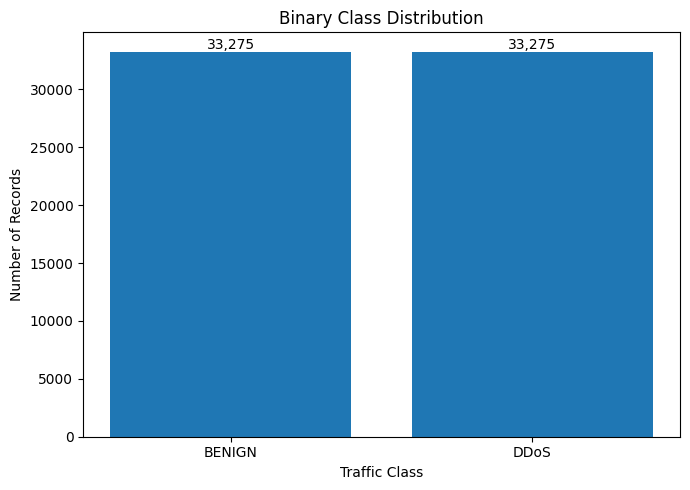

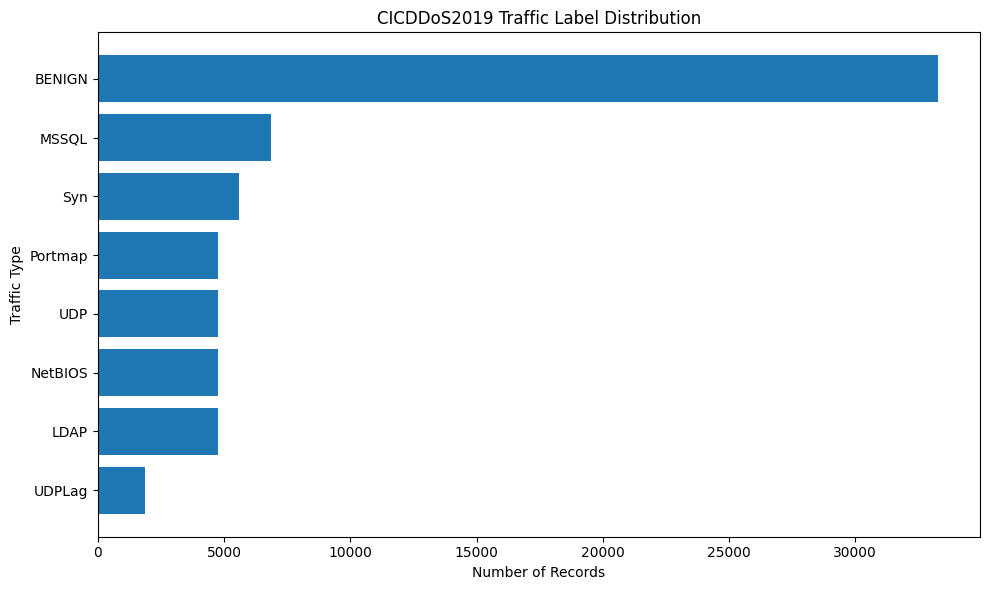

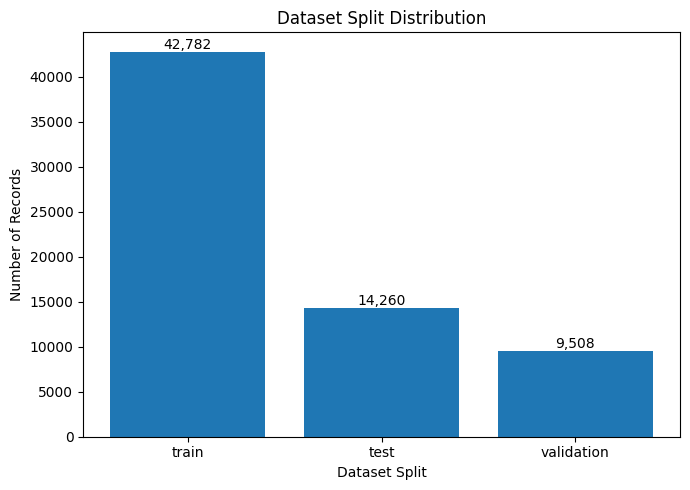


Top 15 features correlated with BinaryLabel:
Inbound                   0.792143
URG Flag Count            0.574130
Min Packet Length         0.569485
Fwd Packet Length Min     0.565572
Fwd Packets/s             0.557504
Flow Packets/s            0.554461
Protocol                  0.547057
Avg Fwd Segment Size      0.533798
Fwd Packet Length Mean    0.533798
Average Packet Size       0.515514
Packet Length Mean        0.492480
Destination Port          0.480590
Flow Bytes/s              0.476413
Down/Up Ratio             0.467980
Source Port               0.373211
Name: BinaryLabel, dtype: float64


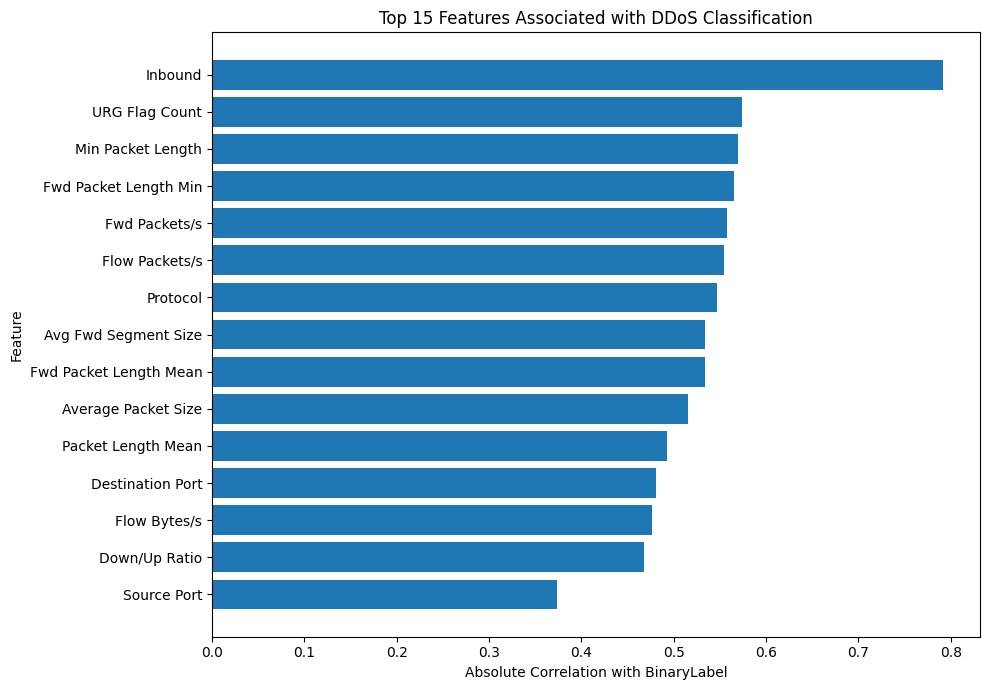

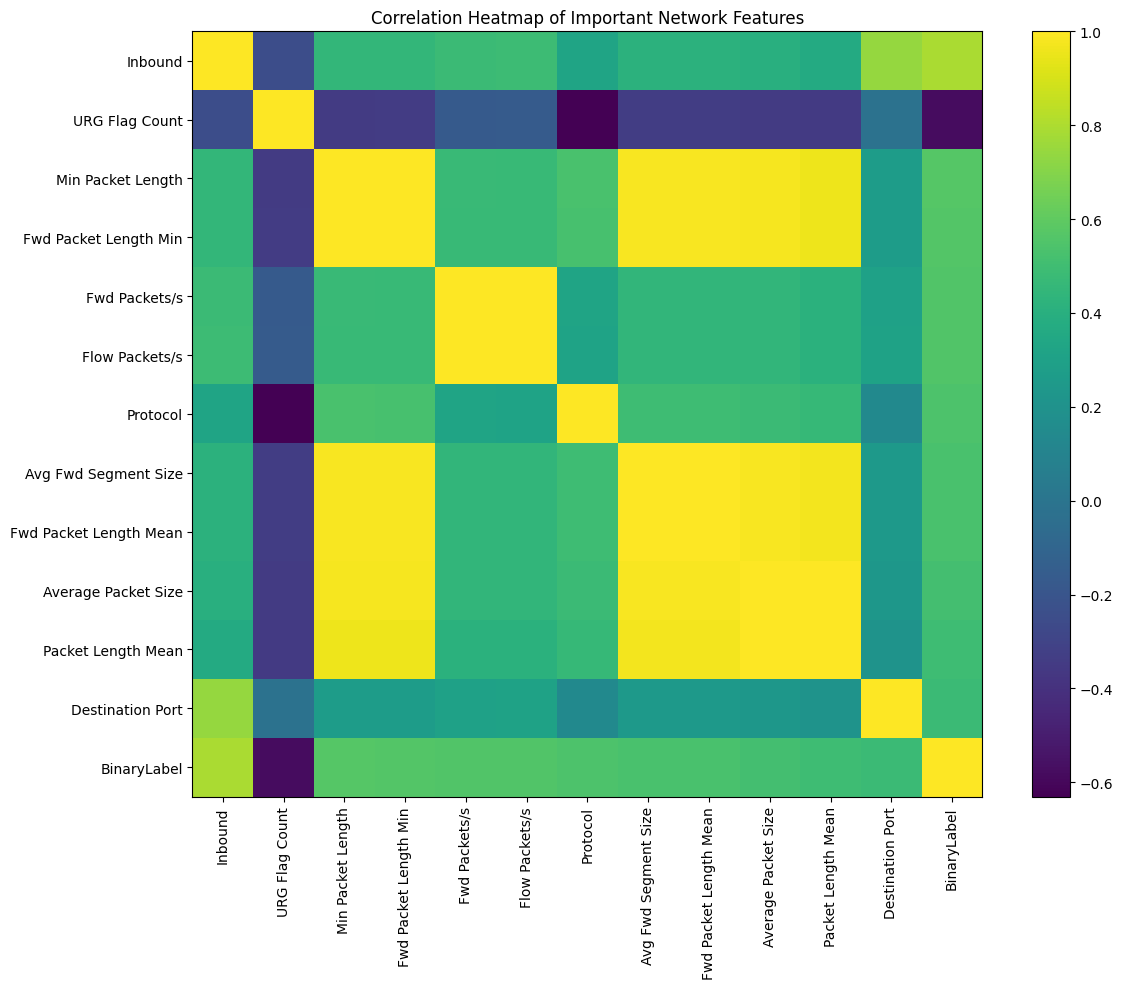

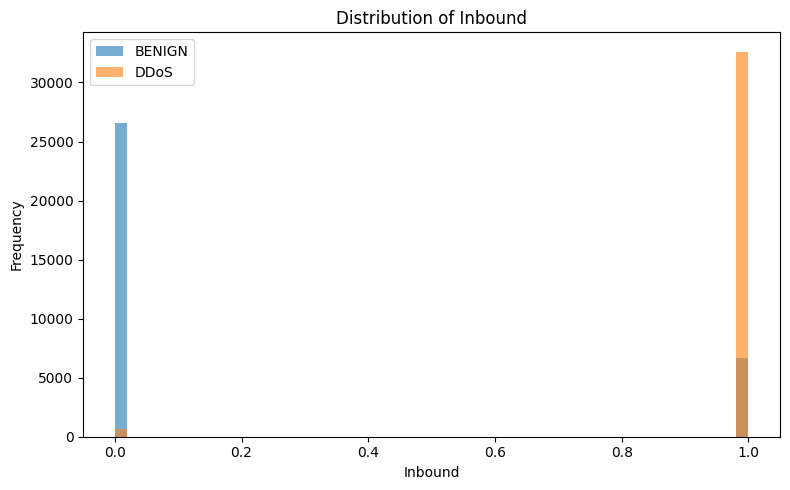

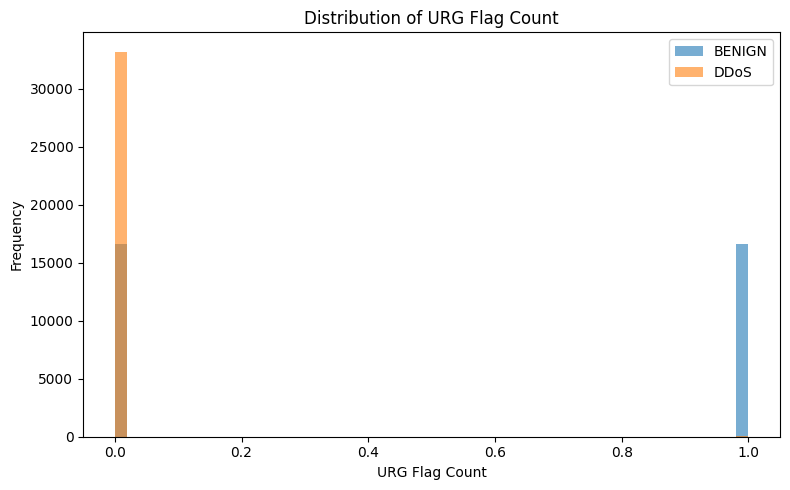

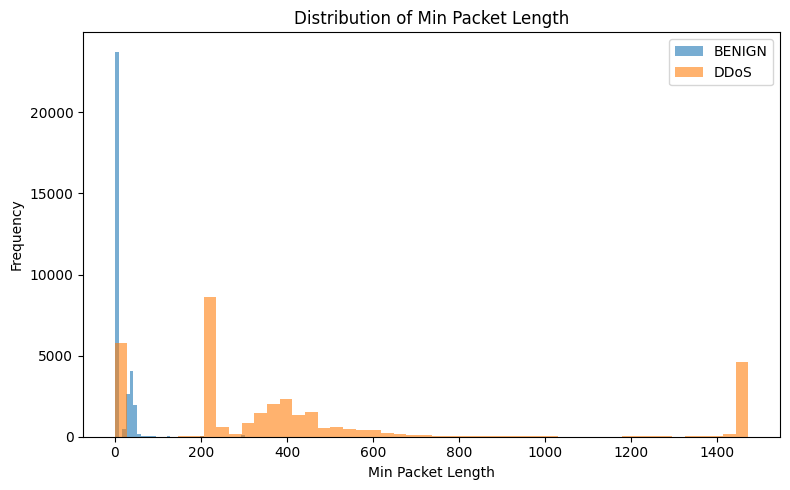

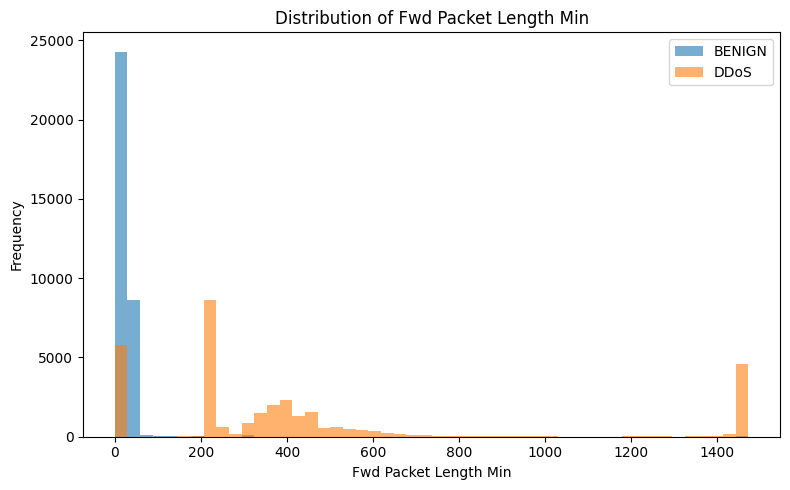

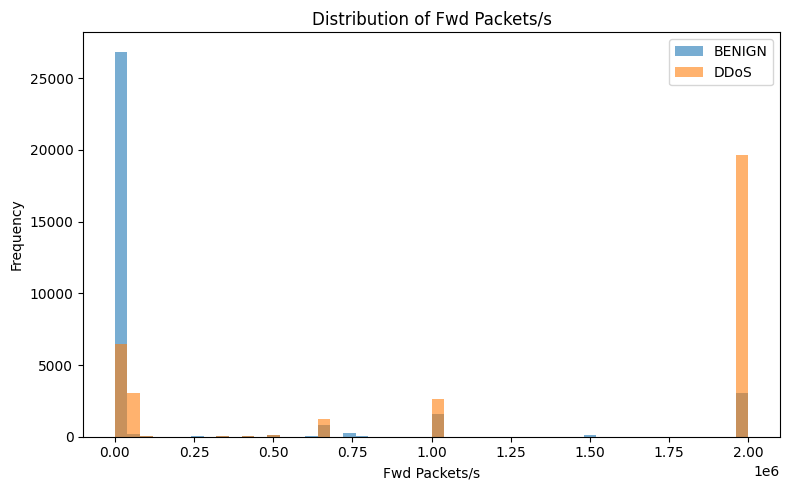

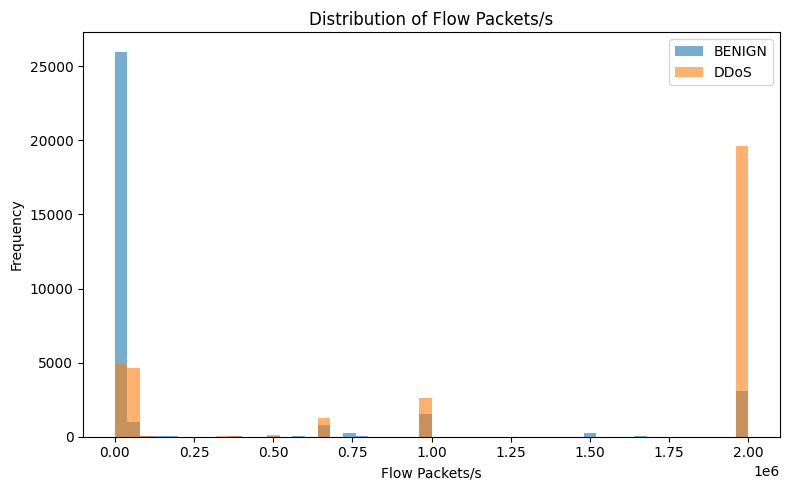

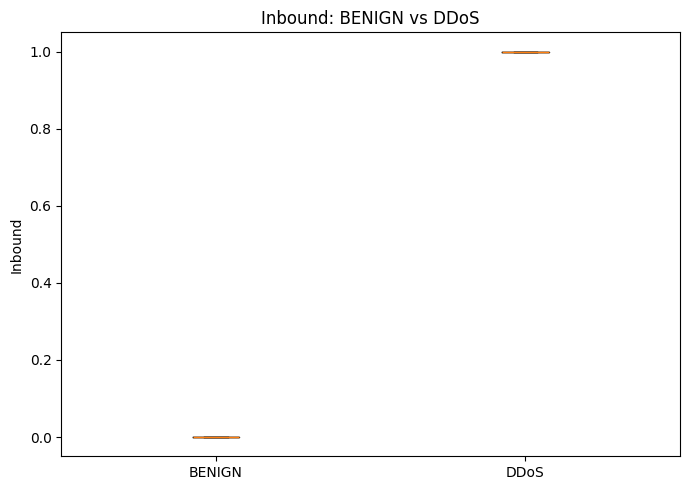

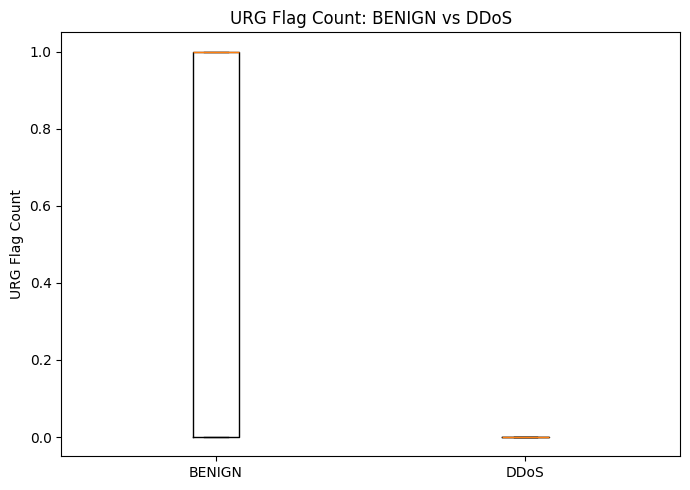

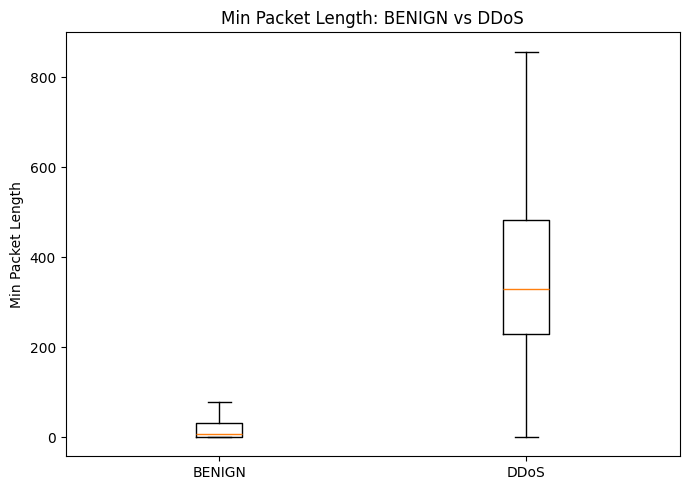

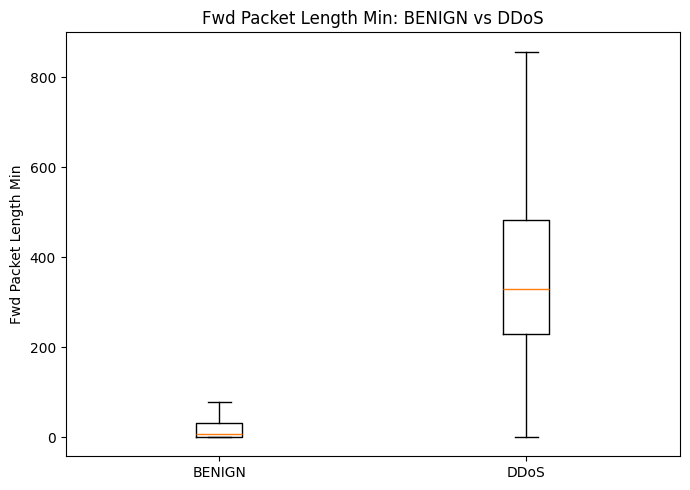

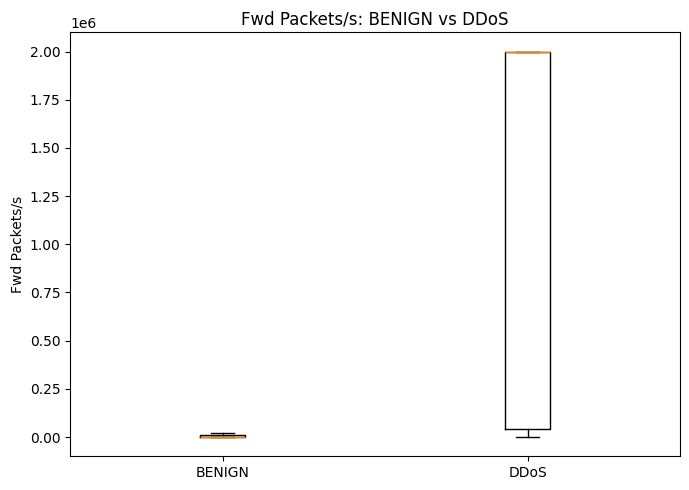

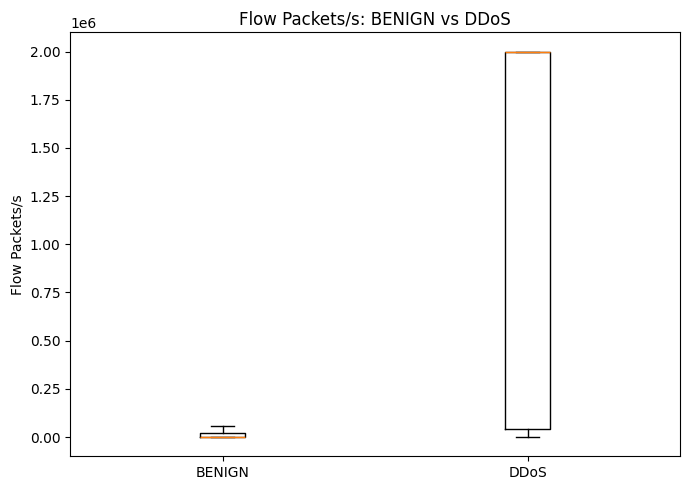


EDA COMPLETE
rows: 66550
columns: 71
ml_features: 68
benign_rows: 33275
ddos_rows: 33275
missing_values: 0
duplicate_rows: 118

Graphs saved to: /content/drive/MyDrive/ML proj/DDoS_LSTM_Autoencoder_Project/results/eda

✅ EDA completed successfully


In [7]:
# ============================================================
# 2. EXPLORATORY DATA ANALYSIS (EDA)
# ============================================================

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from pathlib import Path

# Create folders for project results
RESULTS_DIR = PROJECT_ROOT / "results"
EDA_DIR = RESULTS_DIR / "eda"

RESULTS_DIR.mkdir(exist_ok=True)
EDA_DIR.mkdir(exist_ok=True)

print("EDA output folder:", EDA_DIR)


# ------------------------------------------------------------
# 1. Dataset summary
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("DATASET SUMMARY")
print("=" * 60)

print("Rows:", df.shape[0])
print("Columns:", df.shape[1])
print("ML Features:", len(feature_columns))

print("\nBinary class distribution:")
print(df["BinaryLabel"].value_counts())

print("\nAttack label distribution:")
print(df["Label"].value_counts())


# ------------------------------------------------------------
# 2. Binary Class Distribution
# ------------------------------------------------------------

class_counts = df["BinaryLabel"].value_counts().sort_index()

plt.figure(figsize=(7, 5))

plt.bar(
    ["BENIGN", "DDoS"],
    [
        class_counts.get(0, 0),
        class_counts.get(1, 0)
    ]
)

plt.title("Binary Class Distribution")
plt.xlabel("Traffic Class")
plt.ylabel("Number of Records")

for i, value in enumerate([
    class_counts.get(0, 0),
    class_counts.get(1, 0)
]):
    plt.text(
        i,
        value,
        f"{value:,}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()

plt.savefig(
    EDA_DIR / "01_binary_class_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ------------------------------------------------------------
# 3. Attack Type Distribution
# ------------------------------------------------------------

attack_counts = (
    df["Label"]
    .value_counts()
    .sort_values(ascending=True)
)

plt.figure(figsize=(10, 6))

plt.barh(
    attack_counts.index,
    attack_counts.values
)

plt.title("CICDDoS2019 Traffic Label Distribution")
plt.xlabel("Number of Records")
plt.ylabel("Traffic Type")

plt.tight_layout()

plt.savefig(
    EDA_DIR / "02_attack_type_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ------------------------------------------------------------
# 4. Train / Validation / Test Distribution
# ------------------------------------------------------------

split_counts = df["Split"].value_counts()

plt.figure(figsize=(7, 5))

plt.bar(
    split_counts.index,
    split_counts.values
)

plt.title("Dataset Split Distribution")
plt.xlabel("Dataset Split")
plt.ylabel("Number of Records")

for i, value in enumerate(split_counts.values):
    plt.text(
        i,
        value,
        f"{value:,}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()

plt.savefig(
    EDA_DIR / "03_dataset_split_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ------------------------------------------------------------
# 5. Select numeric features for correlation analysis
# ------------------------------------------------------------

model_features = [
    c for c in feature_columns
    if pd.api.types.is_numeric_dtype(df[c])
]

correlations = (
    df[model_features + ["BinaryLabel"]]
    .corr(numeric_only=True)["BinaryLabel"]
    .drop("BinaryLabel")
    .abs()
    .sort_values(ascending=False)
)

top_features = correlations.head(15)

print("\nTop 15 features correlated with BinaryLabel:")
print(top_features)


# ------------------------------------------------------------
# 6. Top Feature Correlation Plot
# ------------------------------------------------------------

plt.figure(figsize=(10, 7))

plt.barh(
    top_features.index[::-1],
    top_features.values[::-1]
)

plt.title("Top 15 Features Associated with DDoS Classification")
plt.xlabel("Absolute Correlation with BinaryLabel")
plt.ylabel("Feature")

plt.tight_layout()

plt.savefig(
    EDA_DIR / "04_top_feature_correlations.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ------------------------------------------------------------
# 7. Correlation Heatmap for top 12 features
# ------------------------------------------------------------

heatmap_features = list(top_features.head(12).index)

corr_matrix = (
    df[heatmap_features + ["BinaryLabel"]]
    .corr(numeric_only=True)
)

fig, ax = plt.subplots(figsize=(12, 10))

im = ax.imshow(
    corr_matrix.values,
    aspect="auto"
)

ax.set_xticks(
    np.arange(len(corr_matrix.columns))
)

ax.set_yticks(
    np.arange(len(corr_matrix.columns))
)

ax.set_xticklabels(
    corr_matrix.columns,
    rotation=90
)

ax.set_yticklabels(
    corr_matrix.columns
)

fig.colorbar(im)

ax.set_title(
    "Correlation Heatmap of Important Network Features"
)

plt.tight_layout()

plt.savefig(
    EDA_DIR / "05_correlation_heatmap.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ------------------------------------------------------------
# 8. Feature Histograms
# ------------------------------------------------------------

hist_features = list(top_features.head(6).index)

for feature in hist_features:

    plt.figure(figsize=(8, 5))

    benign_values = df.loc[
        df["BinaryLabel"] == 0,
        feature
    ]

    attack_values = df.loc[
        df["BinaryLabel"] == 1,
        feature
    ]

    # Clip extreme tails only for visualization.
    low = df[feature].quantile(0.01)
    high = df[feature].quantile(0.99)

    benign_plot = benign_values.clip(low, high)
    attack_plot = attack_values.clip(low, high)

    plt.hist(
        benign_plot,
        bins=50,
        alpha=0.6,
        label="BENIGN"
    )

    plt.hist(
        attack_plot,
        bins=50,
        alpha=0.6,
        label="DDoS"
    )

    plt.title(
        f"Distribution of {feature}"
    )

    plt.xlabel(feature)
    plt.ylabel("Frequency")

    plt.legend()

    plt.tight_layout()

    safe_name = (
        feature
        .replace("/", "_")
        .replace(" ", "_")
    )

    plt.savefig(
        EDA_DIR /
        f"hist_{safe_name}.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()


# ------------------------------------------------------------
# 9. Boxplots for top features
# ------------------------------------------------------------

for feature in hist_features:

    benign_values = df.loc[
        df["BinaryLabel"] == 0,
        feature
    ]

    attack_values = df.loc[
        df["BinaryLabel"] == 1,
        feature
    ]

    low = df[feature].quantile(0.01)
    high = df[feature].quantile(0.99)

    benign_plot = benign_values.clip(low, high)
    attack_plot = attack_values.clip(low, high)

    plt.figure(figsize=(7, 5))

    plt.boxplot(
        [
            benign_plot,
            attack_plot
        ],
        labels=[
            "BENIGN",
            "DDoS"
        ],
        showfliers=False
    )

    plt.title(
        f"{feature}: BENIGN vs DDoS"
    )

    plt.ylabel(feature)

    plt.tight_layout()

    safe_name = (
        feature
        .replace("/", "_")
        .replace(" ", "_")
    )

    plt.savefig(
        EDA_DIR /
        f"box_{safe_name}.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()


# ------------------------------------------------------------
# 10. EDA summary
# ------------------------------------------------------------

eda_summary = {
    "rows": int(df.shape[0]),
    "columns": int(df.shape[1]),
    "ml_features": int(len(feature_columns)),
    "benign_rows": int(
        (df["BinaryLabel"] == 0).sum()
    ),
    "ddos_rows": int(
        (df["BinaryLabel"] == 1).sum()
    ),
    "missing_values": int(
        df.isnull().sum().sum()
    ),
    "duplicate_rows": int(
        df.duplicated().sum()
    )
}

print("\n" + "=" * 60)
print("EDA COMPLETE")
print("=" * 60)

for key, value in eda_summary.items():
    print(f"{key}: {value}")

print(
    "\nGraphs saved to:",
    EDA_DIR
)

print("\n✅ EDA completed successfully")

## 3. Preprocessing

In [8]:
from sklearn.preprocessing import StandardScaler
import joblib

# Use existing split if present; otherwise create stratified split
if 'Split' in df.columns:
    train_df = df[df['Split'] == 'train'].copy()
    val_df = df[df['Split'] == 'validation'].copy()
    test_df = df[df['Split'] == 'test'].copy()
else:
    from sklearn.model_selection import train_test_split
    train_val, test_df = train_test_split(df, test_size=0.214, stratify=df['Label'], random_state=RANDOM_STATE)
    train_df, val_df = train_test_split(train_val, test_size=0.182, stratify=train_val['Label'], random_state=RANDOM_STATE)

print('Train:', train_df.shape)
print('Validation:', val_df.shape)
print('Test:', test_df.shape)

non_feature_cols = ['Label', 'BinaryLabel', 'Split']
feature_cols = [c for c in train_df.select_dtypes(include=[np.number]).columns if c not in non_feature_cols]

X_train = train_df[feature_cols].replace([np.inf, -np.inf], np.nan)
X_val = val_df[feature_cols].replace([np.inf, -np.inf], np.nan)
X_test = test_df[feature_cols].replace([np.inf, -np.inf], np.nan)

# Training-only median imputation
medians = X_train.median(numeric_only=True)
X_train = X_train.fillna(medians)
X_val = X_val.fillna(medians)
X_test = X_test.fillna(medians)

y_train = train_df['BinaryLabel'].astype(int).values
y_val = val_df['BinaryLabel'].astype(int).values
y_test = test_df['BinaryLabel'].astype(int).values

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

joblib.dump(scaler, MODEL_DIR / 'standard_scaler.joblib')
with open(MODEL_DIR / 'feature_columns.json', 'w') as f:
    json.dump(feature_cols, f, indent=2)

print('Features used:', len(feature_cols))
print('Scaled shapes:', X_train_scaled.shape, X_val_scaled.shape, X_test_scaled.shape)

Train: (42782, 71)
Validation: (9508, 71)
Test: (14260, 71)
Features used: 68
Scaled shapes: (42782, 68) (9508, 68) (14260, 68)


## 4. Logistic Regression Baseline

In [9]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, average_precision_score, confusion_matrix, classification_report, roc_curve, precision_recall_curve

metrics = {}

lr = LogisticRegression(max_iter=1000, class_weight='balanced', n_jobs=-1)
lr.fit(X_train_scaled, y_train)

lr_prob = lr.predict_proba(X_test_scaled)[:, 1]
lr_pred = (lr_prob >= 0.5).astype(int)

metrics['Logistic Regression'] = {
    'accuracy': float(accuracy_score(y_test, lr_pred)),
    'precision': float(precision_score(y_test, lr_pred)),
    'recall': float(recall_score(y_test, lr_pred)),
    'f1': float(f1_score(y_test, lr_pred)),
    'roc_auc': float(roc_auc_score(y_test, lr_prob)),
    'pr_auc': float(average_precision_score(y_test, lr_prob)),
}
print(metrics['Logistic Regression'])
print(classification_report(y_test, lr_pred))
joblib.dump(lr, MODEL_DIR / 'logistic_regression.joblib')

{'accuracy': 0.9978260869565218, 'precision': 0.9988756148981026, 'recall': 0.9967741935483871, 'f1': 0.9978237978237978, 'roc_auc': 0.9992696446872252, 'pr_auc': 0.999488871896474}
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      7130
           1       1.00      1.00      1.00      7130

    accuracy                           1.00     14260
   macro avg       1.00      1.00      1.00     14260
weighted avg       1.00      1.00      1.00     14260



['/content/drive/MyDrive/ML proj/DDoS_LSTM_Autoencoder_Project/backend/saved_models/logistic_regression.joblib']

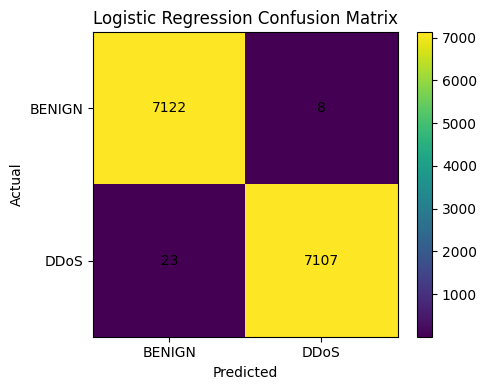

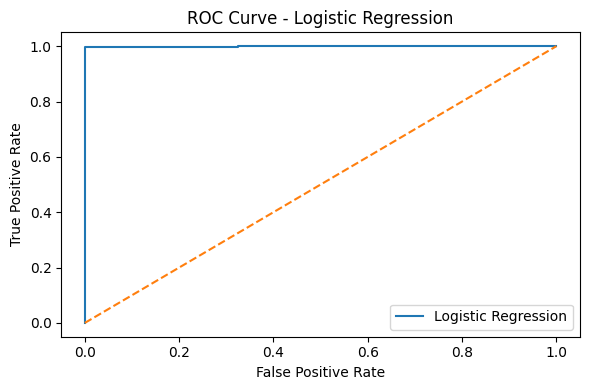

In [10]:
def save_confusion_matrix(y_true, y_pred, title, filename):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(5,4))
    plt.imshow(cm)
    plt.title(title)
    plt.colorbar()
    plt.xticks([0,1], ['BENIGN','DDoS'])
    plt.yticks([0,1], ['BENIGN','DDoS'])
    for i in range(2):
        for j in range(2):
            plt.text(j, i, cm[i, j], ha='center', va='center')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.tight_layout()
    plt.savefig(GRAPH_DIR / filename, dpi=160)
    plt.show()

save_confusion_matrix(y_test, lr_pred, 'Logistic Regression Confusion Matrix', 'lr_confusion_matrix.png')

fpr, tpr, _ = roc_curve(y_test, lr_prob)
plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, label='Logistic Regression')
plt.plot([0,1], [0,1], linestyle='--')
plt.title('ROC Curve - Logistic Regression')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.tight_layout()
plt.savefig(GRAPH_DIR / 'lr_roc_curve.png', dpi=160)
plt.show()

## 5. LSTM Model

In [11]:
# ============================================================
# LSTM - TEMPORAL SEQUENCE MODEL
# ============================================================

import numpy as np
import pandas as pd
import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

tf.random.set_seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

SEQ_LEN = 8


# ============================================================
# 1. LOAD CLEAN DATASET WITH TEMPORAL INFORMATION
# ============================================================

CLEAN_DATA_PATH = (
    PROJECT_ROOT
    / "dataset"
    / "CICDDoS2019_66550_Clean.csv"
)

temporal_df = pd.read_csv(
    CLEAN_DATA_PATH,
    low_memory=False
)

print("Clean temporal dataset:", temporal_df.shape)


# ============================================================
# 2. VERIFY REQUIRED COLUMNS
# ============================================================

required_columns = [
    "Timestamp",
    "SourceCSV",
    "BinaryLabel",
    "Split"
]

missing_required = [
    c for c in required_columns
    if c not in temporal_df.columns
]

if missing_required:
    raise ValueError(
        f"Missing temporal columns: {missing_required}"
    )


missing_features = [
    c for c in feature_columns
    if c not in temporal_df.columns
]

if missing_features:
    raise ValueError(
        f"Missing model features: {missing_features}"
    )


print("Temporal metadata found ✅")
print("Model features found:", len(feature_columns))


# ============================================================
# 3. PARSE TIMESTAMP
# ============================================================

temporal_df["Timestamp"] = pd.to_datetime(
    temporal_df["Timestamp"],
    errors="coerce"
)

print(
    "Invalid timestamps:",
    temporal_df["Timestamp"].isna().sum()
)


# Rows with an invalid timestamp cannot safely participate
# in chronological sequence creation.

temporal_df = temporal_df.dropna(
    subset=["Timestamp"]
).copy()


# ============================================================
# 4. CREATE TEMPORAL SEQUENCES
# ============================================================

def make_temporal_sequences(
    data,
    split_name,
    seq_len=8
):

    split_df = data[
        data["Split"] == split_name
    ].copy()

    X_sequences = []
    y_sequences = []

    source_sequence_counts = {}

    # IMPORTANT:
    # Never allow a sequence to cross from one source CSV
    # into another source CSV.

    for source_name, group in split_df.groupby(
        "SourceCSV"
    ):

        # Chronological order
        group = group.sort_values(
            "Timestamp"
        ).reset_index(drop=True)

        if len(group) < seq_len:
            continue

        # Use exactly the same 68 features
        # used by Logistic Regression.

        X_group = group[
            feature_columns
        ].astype(np.float32)

        y_group = group[
            "BinaryLabel"
        ].astype(np.int32).to_numpy()

        # Apply the SAME scaler fitted only
        # on training data during preprocessing.

        X_group_scaled = scaler.transform(
            X_group
        ).astype(np.float32)

        count = 0

        for i in range(
            len(X_group_scaled) - seq_len + 1
        ):

            X_sequences.append(
                X_group_scaled[
                    i:i + seq_len
                ]
            )

            # Target = state of final flow
            # in the temporal window.

            y_sequences.append(
                y_group[
                    i + seq_len - 1
                ]
            )

            count += 1

        source_sequence_counts[
            source_name
        ] = count

    X_sequences = np.asarray(
        X_sequences,
        dtype=np.float32
    )

    y_sequences = np.asarray(
        y_sequences,
        dtype=np.int32
    )

    print(
        f"\n{split_name.upper()} sequences:",
        X_sequences.shape
    )

    print(
        f"{split_name.upper()} labels:",
        y_sequences.shape
    )

    print(
        f"{split_name.upper()} class counts:",
        np.bincount(y_sequences)
    )

    print(
        f"{split_name.upper()} source groups:",
        source_sequence_counts
    )

    return X_sequences, y_sequences


# ============================================================
# 5. BUILD TRAIN / VALIDATION / TEST SEQUENCES
# ============================================================

X_train_seq, y_train_seq = make_temporal_sequences(
    temporal_df,
    "train",
    SEQ_LEN
)

X_val_seq, y_val_seq = make_temporal_sequences(
    temporal_df,
    "validation",
    SEQ_LEN
)

X_test_seq, y_test_seq = make_temporal_sequences(
    temporal_df,
    "test",
    SEQ_LEN
)


print("\n" + "=" * 60)
print("FINAL LSTM INPUT SHAPES")
print("=" * 60)

print(
    "Train:",
    X_train_seq.shape,
    y_train_seq.shape
)

print(
    "Validation:",
    X_val_seq.shape,
    y_val_seq.shape
)

print(
    "Test:",
    X_test_seq.shape,
    y_test_seq.shape
)


# ============================================================
# 6. BUILD LSTM MODEL
# ============================================================

lstm_model = Sequential([

    Input(
        shape=(
            SEQ_LEN,
            len(feature_columns)
        )
    ),

    LSTM(
        64,
        return_sequences=True
    ),

    Dropout(0.30),

    LSTM(32),

    Dropout(0.20),

    Dense(
        16,
        activation="relu"
    ),

    Dense(
        1,
        activation="sigmoid"
    )
])


lstm_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)


print("\nLSTM MODEL ARCHITECTURE")
print("=" * 60)

lstm_model.summary()


# ============================================================
# 7. CALLBACKS
# ============================================================

lstm_ckpt = (
    MODEL_DIR
    / "lstm_model.keras"
)


callbacks = [

    EarlyStopping(
        monitor="val_loss",
        patience=3,
        restore_best_weights=True
    ),

    ModelCheckpoint(
        str(lstm_ckpt),
        monitor="val_loss",
        save_best_only=True
    )
]


# ============================================================
# 8. TRAIN LSTM
# ============================================================

history = lststm_history = lstm_model.fit(

    X_train_seq,
    y_train_seq,

    validation_data=(
        X_val_seq,
        y_val_seq
    ),

    epochs=15,

    batch_size=256,

    callbacks=callbacks,

    verbose=1
)


# ============================================================
# 9. SAVE FINAL MODEL
# ============================================================

FINAL_LSTM_PATH = (
    MODEL_DIR
    / "lstm_model_final.keras"
)

lstm_model.save(
    FINAL_LSTM_PATH
)


print("\n" + "=" * 60)
print("LSTM TRAINING COMPLETE")
print("=" * 60)

print(
    "Best model:",
    lstm_ckpt
)

print(
    "Final model:",
    FINAL_LSTM_PATH
)

print("\n✅ Temporal LSTM model saved successfully")

Clean temporal dataset: (66550, 89)
Temporal metadata found ✅
Model features found: 68
Invalid timestamps: 0

TRAIN sequences: (42733, 8, 68)
TRAIN labels: (42733,)
TRAIN class counts: [21375 21358]
TRAIN source groups: {'LDAP.csv': 5209, 'MSSQL.csv': 5451, 'NetBIOS.csv': 3399, 'Portmap.csv': 4892, 'Syn.csv': 16259, 'UDP.csv': 4239, 'UDPLag.csv': 3284}

VALIDATION sequences: (9459, 8, 68)
VALIDATION labels: (9459,)
VALIDATION class counts: [4732 4727]
VALIDATION source groups: {'LDAP.csv': 1171, 'MSSQL.csv': 1225, 'NetBIOS.csv': 747, 'Portmap.csv': 1084, 'Syn.csv': 3552, 'UDP.csv': 933, 'UDPLag.csv': 747}

TEST sequences: (14211, 8, 68)
TEST labels: (14211,)
TEST class counts: [7114 7097]
TEST source groups: {'LDAP.csv': 1738, 'MSSQL.csv': 1836, 'NetBIOS.csv': 1155, 'Portmap.csv': 1612, 'Syn.csv': 5393, 'UDP.csv': 1395, 'UDPLag.csv': 1082}

FINAL LSTM INPUT SHAPES
Train: (42733, 8, 68) (42733,)
Validation: (9459, 8, 68) (9459,)
Test: (14211, 8, 68) (14211,)

LSTM MODEL ARCHITECTURE


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 8, 64)          │        34,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 8, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 47,009 (183.63 KB)

 Trainable params: 47,009 (183.63 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/15
167/167 ━━━━━━━━━━━━━━━━━━━━ 7s 16ms/step - accuracy: 0.9459 - loss: 0.1691 - val_accuracy: 0.9958 - val_loss: 0.0196
Epoch 2/15
167/167 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9962 - loss: 0.0169 - val_accuracy: 0.9973 - val_loss: 0.0115
Epoch 3/15
167/167 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9973 - loss: 0.0110 - val_accuracy: 0.9980 - val_loss: 0.0083
Epoch 4/15
167/167 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9983 - loss: 0.0074 - val_accuracy: 0.9982 - val_loss: 0.0069
Epoch 5/15
167/167 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9984 - loss: 0.0063 - val_accuracy: 0.9985 - val_loss: 0.0068
Epoch 6/15
167/167 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9987 - loss: 0.0056 - val_accuracy: 0.9986 - val_loss: 0.0065
Epoch 7/15
167/167 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9988 - loss: 0.0046 - val_accuracy: 0.9987 - val_loss: 0.0061
Epoch 8/15
167/167 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.9990 - loss: 0.0044 - val_accuracy: 

Best LSTM model loaded ✅
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step

LSTM TEST RESULTS
ACCURACY    : 0.998593
PRECISION   : 0.999294
RECALL      : 0.997886
F1          : 0.998590
ROC_AUC     : 0.999902
PR_AUC      : 0.999916

Classification Report:

              precision    recall  f1-score   support

      BENIGN       1.00      1.00      1.00      7114
        DDoS       1.00      1.00      1.00      7097

    accuracy                           1.00     14211
   macro avg       1.00      1.00      1.00     14211
weighted avg       1.00      1.00      1.00     14211


Confusion Matrix:
[[7109    5]
 [  15 7082]]


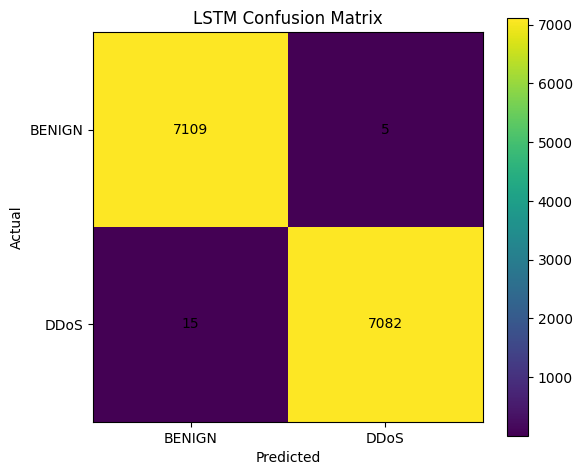

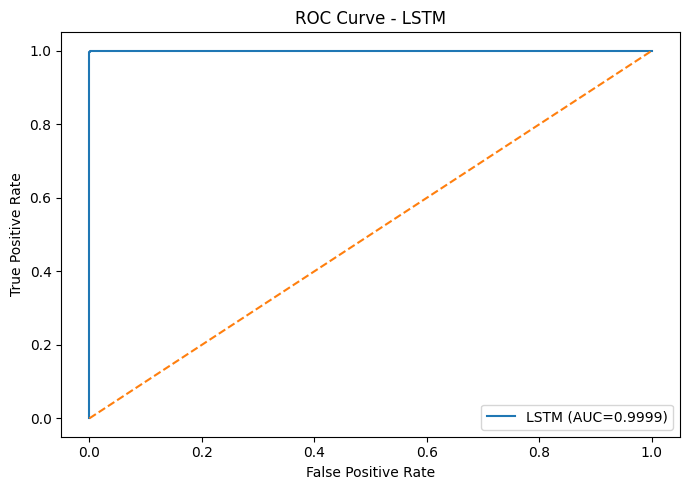

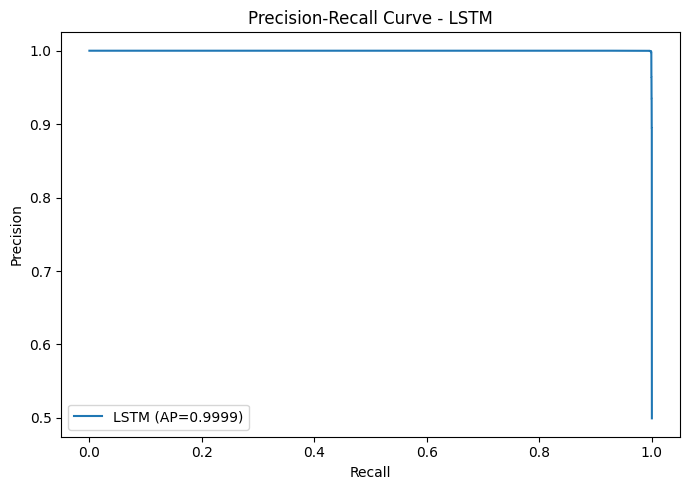

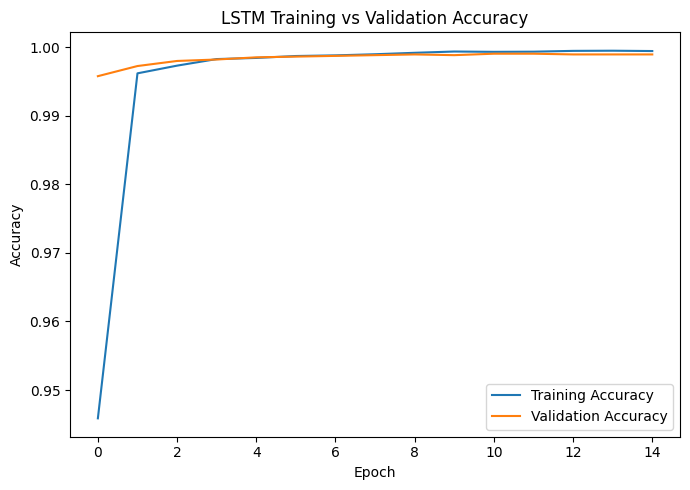

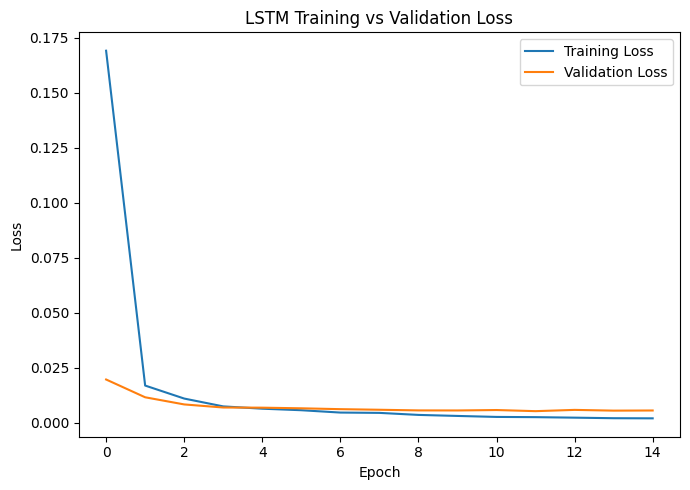


LSTM EVALUATION COMPLETE

Graphs saved in: /content/drive/MyDrive/ML proj/DDoS_LSTM_Autoencoder_Project/results/graphs
Metrics saved as: /content/drive/MyDrive/ML proj/DDoS_LSTM_Autoencoder_Project/results/lstm_metrics.csv

✅ LSTM evaluation completed successfully


In [12]:
# ============================================================
# LSTM EVALUATION
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    classification_report,
    confusion_matrix,
    roc_curve,
    precision_recall_curve
)


# ============================================================
# 1. LOAD BEST LSTM MODEL
# ============================================================

best_lstm = tf.keras.models.load_model(
    MODEL_DIR / "lstm_model.keras"
)

print("Best LSTM model loaded ✅")


# ============================================================
# 2. PREDICT TEST SET
# ============================================================

lstm_prob = best_lstm.predict(
    X_test_seq,
    batch_size=256,
    verbose=1
).ravel()

lstm_pred = (
    lstm_prob >= 0.5
).astype(int)


# ============================================================
# 3. CALCULATE METRICS
# ============================================================

lstm_metrics = {
    "accuracy": accuracy_score(
        y_test_seq,
        lstm_pred
    ),

    "precision": precision_score(
        y_test_seq,
        lstm_pred
    ),

    "recall": recall_score(
        y_test_seq,
        lstm_pred
    ),

    "f1": f1_score(
        y_test_seq,
        lstm_pred
    ),

    "roc_auc": roc_auc_score(
        y_test_seq,
        lstm_prob
    ),

    "pr_auc": average_precision_score(
        y_test_seq,
        lstm_prob
    )
}


print("\n" + "=" * 60)
print("LSTM TEST RESULTS")
print("=" * 60)

for metric, value in lstm_metrics.items():
    print(
        f"{metric.upper():<12}: "
        f"{value:.6f}"
    )


print("\nClassification Report:\n")

print(
    classification_report(
        y_test_seq,
        lstm_pred,
        target_names=[
            "BENIGN",
            "DDoS"
        ]
    )
)


# ============================================================
# 4. CONFUSION MATRIX
# ============================================================

cm = confusion_matrix(
    y_test_seq,
    lstm_pred
)

print("\nConfusion Matrix:")
print(cm)


plt.figure(figsize=(6, 5))

plt.imshow(cm)

plt.title(
    "LSTM Confusion Matrix"
)

plt.colorbar()

plt.xticks(
    [0, 1],
    ["BENIGN", "DDoS"]
)

plt.yticks(
    [0, 1],
    ["BENIGN", "DDoS"]
)

for i in range(2):
    for j in range(2):

        plt.text(
            j,
            i,
            cm[i, j],
            ha="center",
            va="center"
        )

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.tight_layout()

plt.savefig(
    GRAPH_DIR / "lstm_confusion_matrix.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# 5. ROC CURVE
# ============================================================

fpr, tpr, _ = roc_curve(
    y_test_seq,
    lstm_prob
)

plt.figure(figsize=(7, 5))

plt.plot(
    fpr,
    tpr,
    label=(
        f"LSTM "
        f"(AUC={lstm_metrics['roc_auc']:.4f})"
    )
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.xlabel(
    "False Positive Rate"
)

plt.ylabel(
    "True Positive Rate"
)

plt.title(
    "ROC Curve - LSTM"
)

plt.legend()

plt.tight_layout()

plt.savefig(
    GRAPH_DIR / "lstm_roc_curve.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# 6. PRECISION-RECALL CURVE
# ============================================================

precision_curve, recall_curve, _ = (
    precision_recall_curve(
        y_test_seq,
        lstm_prob
    )
)

plt.figure(figsize=(7, 5))

plt.plot(
    recall_curve,
    precision_curve,
    label=(
        f"LSTM "
        f"(AP={lstm_metrics['pr_auc']:.4f})"
    )
)

plt.xlabel("Recall")
plt.ylabel("Precision")

plt.title(
    "Precision-Recall Curve - LSTM"
)

plt.legend()

plt.tight_layout()

plt.savefig(
    GRAPH_DIR / "lstm_pr_curve.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# 7. TRAINING ACCURACY GRAPH
# ============================================================

plt.figure(figsize=(7, 5))

plt.plot(
    history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.title(
    "LSTM Training vs Validation Accuracy"
)

plt.legend()

plt.tight_layout()

plt.savefig(
    GRAPH_DIR /
    "lstm_training_accuracy.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# 8. TRAINING LOSS GRAPH
# ============================================================

plt.figure(figsize=(7, 5))

plt.plot(
    history.history["loss"],
    label="Training Loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.title(
    "LSTM Training vs Validation Loss"
)

plt.legend()

plt.tight_layout()

plt.savefig(
    GRAPH_DIR /
    "lstm_training_loss.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# 9. SAVE LSTM METRICS
# ============================================================

lstm_metrics_df = pd.DataFrame(
    [lstm_metrics]
)

lstm_metrics_df.to_csv(
    RESULTS_DIR /
    "lstm_metrics.csv",
    index=False
)


print("\n" + "=" * 60)
print("LSTM EVALUATION COMPLETE")
print("=" * 60)

print(
    "\nGraphs saved in:",
    GRAPH_DIR
)

print(
    "Metrics saved as:",
    RESULTS_DIR / "lstm_metrics.csv"
)

print(
    "\n✅ LSTM evaluation completed successfully"
)

## 6. Autoencoder Anomaly Detection

Total training samples: 42782
BENIGN samples used to train Autoencoder: 21391
Input features: 68

AUTOENCODER ARCHITECTURE


Model: "DDoS_Autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ network_features (InputLayer)   │ (None, 68)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 48)             │         3,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 48)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 24)             │         1,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ latent_space (Dense)            │ (None, 12)             │           300 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 24)             │           312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 48)             │         1,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 68)             │         3,332 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,632 (37.62 KB)

 Trainable params: 9,632 (37.62 KB)

 Non-trainable params: 0 (0.00 B)


BENIGN validation samples: 4754
Epoch 1/30
84/84 ━━━━━━━━━━━━━━━━━━━━ 6s 32ms/step - loss: 1.1870 - val_loss: 0.7200
Epoch 2/30
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.7323 - val_loss: 0.5309
Epoch 3/30
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.5676 - val_loss: 0.4537
Epoch 4/30
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.4847 - val_loss: 0.3988
Epoch 5/30
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.4234 - val_loss: 0.3551
Epoch 6/30
84/84 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.3761 - val_loss: 0.3155
Epoch 7/30
84/84 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.3412 - val_loss: 0.2935
Epoch 8/30
84/84 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.3274 - val_loss: 0.2783
Epoch 9/30
84/84 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.2905 - val_loss: 0.2538
Epoch 10/30
84/84 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.2740 - val_loss: 0.2374
Epoch 11/30
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.2637 - val_loss: 0.2247
Epoch 12/30
84/84 ━━━━━━━━━━━━━━━━━━━━ 0

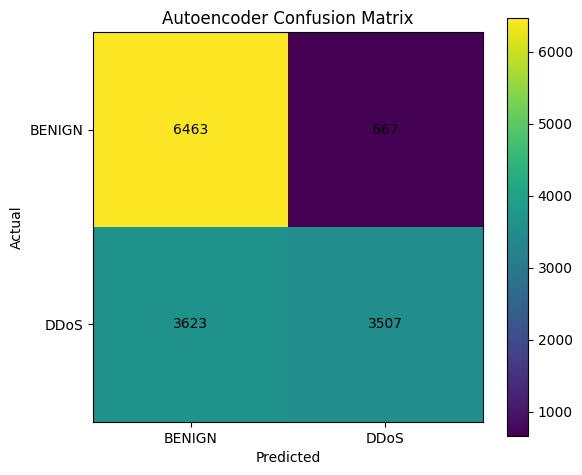

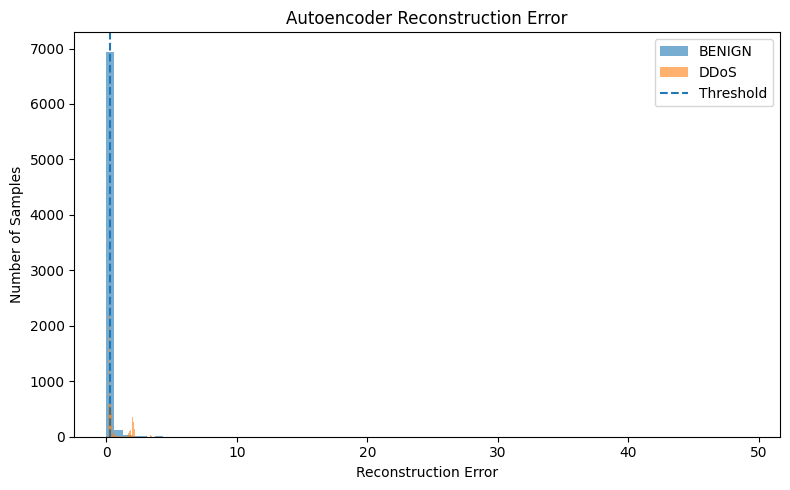

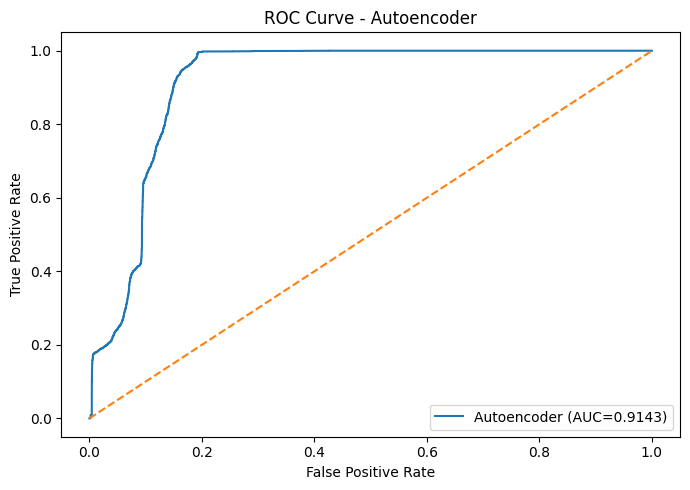

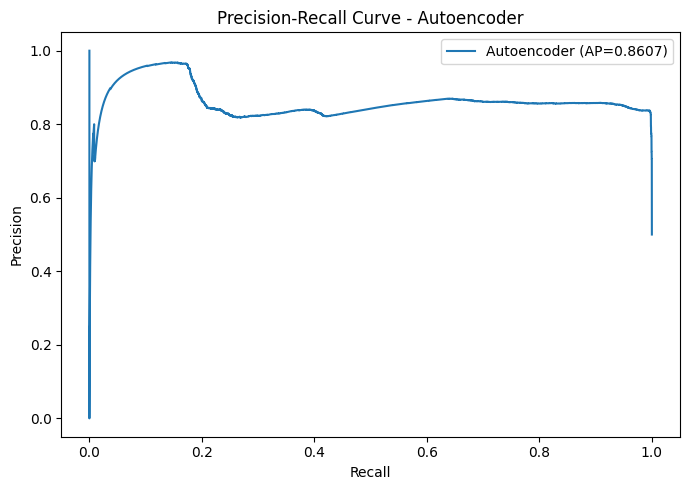

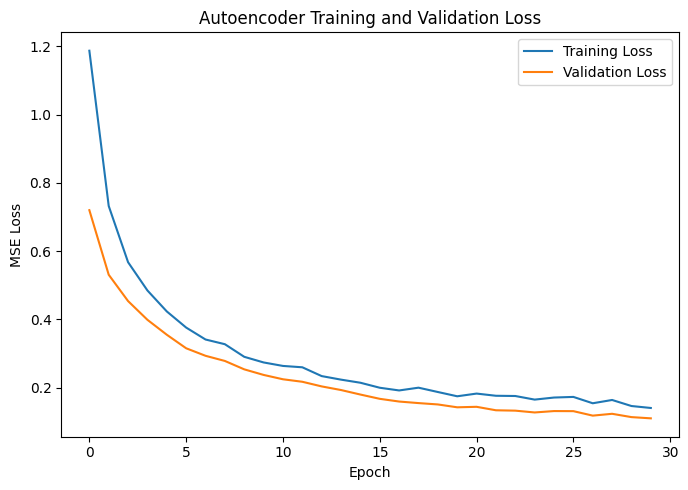


AUTOENCODER COMPLETE
Best model: /content/drive/MyDrive/ML proj/DDoS_LSTM_Autoencoder_Project/backend/saved_models/autoencoder_model.keras
Final model: /content/drive/MyDrive/ML proj/DDoS_LSTM_Autoencoder_Project/backend/saved_models/autoencoder_model_final.keras
Threshold: 0.25912901864863264

✅ Autoencoder evaluation completed successfully


In [13]:
# ============================================================
# AUTOENCODER - UNSUPERVISED ANOMALY DETECTION
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    classification_report,
    confusion_matrix,
    roc_curve,
    precision_recall_curve
)

tf.random.set_seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)


# ============================================================
# 1. USE ONLY BENIGN TRAINING TRAFFIC
# ============================================================

X_train_benign = X_train_scaled[
    y_train == 0
]

print(
    "Total training samples:",
    len(X_train_scaled)
)

print(
    "BENIGN samples used to train Autoencoder:",
    len(X_train_benign)
)

print(
    "Input features:",
    X_train_benign.shape[1]
)


# ============================================================
# 2. BUILD AUTOENCODER
# ============================================================

input_dim = X_train_benign.shape[1]

input_layer = Input(
    shape=(input_dim,),
    name="network_features"
)

# Encoder

x = Dense(
    48,
    activation="relu"
)(input_layer)

x = Dropout(0.10)(x)

x = Dense(
    24,
    activation="relu"
)(x)

latent = Dense(
    12,
    activation="relu",
    name="latent_space"
)(x)


# Decoder

x = Dense(
    24,
    activation="relu"
)(latent)

x = Dense(
    48,
    activation="relu"
)(x)

output_layer = Dense(
    input_dim,
    activation="linear"
)(x)


autoencoder = Model(
    input_layer,
    output_layer,
    name="DDoS_Autoencoder"
)


autoencoder.compile(
    optimizer="adam",
    loss="mse"
)


print("\nAUTOENCODER ARCHITECTURE")
print("=" * 60)

autoencoder.summary()


# ============================================================
# 3. VALIDATION DATA FOR TRAINING
# ============================================================

# Only BENIGN validation samples are used for
# validation loss during Autoencoder training.

X_val_benign = X_val_scaled[
    y_val == 0
]


print(
    "\nBENIGN validation samples:",
    len(X_val_benign)
)


# ============================================================
# 4. CALLBACKS
# ============================================================

ae_checkpoint = (
    MODEL_DIR /
    "autoencoder_model.keras"
)


ae_callbacks = [

    EarlyStopping(
        monitor="val_loss",
        patience=4,
        restore_best_weights=True
    ),

    ModelCheckpoint(
        str(ae_checkpoint),
        monitor="val_loss",
        save_best_only=True
    )
]


# ============================================================
# 5. TRAIN AUTOENCODER
# ============================================================

ae_history = autoencoder.fit(

    X_train_benign,
    X_train_benign,

    validation_data=(
        X_val_benign,
        X_val_benign
    ),

    epochs=30,

    batch_size=256,

    shuffle=True,

    callbacks=ae_callbacks,

    verbose=1
)


# ============================================================
# 6. SAVE FINAL AUTOENCODER
# ============================================================

FINAL_AE_PATH = (
    MODEL_DIR /
    "autoencoder_model_final.keras"
)

autoencoder.save(
    FINAL_AE_PATH
)


print("\n✅ Autoencoder training complete")


# ============================================================
# 7. LOAD BEST MODEL
# ============================================================

best_autoencoder = (
    tf.keras.models.load_model(
        ae_checkpoint
    )
)


# ============================================================
# 8. CALCULATE VALIDATION RECONSTRUCTION ERROR
# ============================================================

val_reconstructed = best_autoencoder.predict(
    X_val_scaled,
    batch_size=256,
    verbose=0
)

val_error = np.mean(
    np.square(
        X_val_scaled -
        val_reconstructed
    ),
    axis=1
)


# ============================================================
# 9. SELECT THRESHOLD USING VALIDATION SET ONLY
# ============================================================

threshold_candidates = np.percentile(
    val_error,
    np.linspace(70, 99.9, 400)
)

best_threshold = None
best_val_f1 = -1


for threshold in threshold_candidates:

    val_predictions = (
        val_error > threshold
    ).astype(int)

    current_f1 = f1_score(
        y_val,
        val_predictions
    )

    if current_f1 > best_val_f1:

        best_val_f1 = current_f1
        best_threshold = threshold


print("\n" + "=" * 60)
print("AUTOENCODER THRESHOLD")
print("=" * 60)

print(
    "Best validation threshold:",
    best_threshold
)

print(
    "Validation F1 at threshold:",
    best_val_f1
)


# ============================================================
# 10. TEST SET RECONSTRUCTION ERROR
# ============================================================

test_reconstructed = best_autoencoder.predict(
    X_test_scaled,
    batch_size=256,
    verbose=1
)

test_error = np.mean(
    np.square(
        X_test_scaled -
        test_reconstructed
    ),
    axis=1
)


# High reconstruction error = anomaly = DDoS

ae_pred = (
    test_error >
    best_threshold
).astype(int)


# ============================================================
# 11. TEST METRICS
# ============================================================

ae_metrics = {

    "accuracy":
        accuracy_score(
            y_test,
            ae_pred
        ),

    "precision":
        precision_score(
            y_test,
            ae_pred,
            zero_division=0
        ),

    "recall":
        recall_score(
            y_test,
            ae_pred,
            zero_division=0
        ),

    "f1":
        f1_score(
            y_test,
            ae_pred,
            zero_division=0
        ),

    "roc_auc":
        roc_auc_score(
            y_test,
            test_error
        ),

    "pr_auc":
        average_precision_score(
            y_test,
            test_error
        )
}


print("\n" + "=" * 60)
print("AUTOENCODER TEST RESULTS")
print("=" * 60)

for metric, value in ae_metrics.items():

    print(
        f"{metric.upper():<12}: "
        f"{value:.6f}"
    )


print("\nClassification Report:\n")

print(
    classification_report(
        y_test,
        ae_pred,
        target_names=[
            "BENIGN",
            "DDoS"
        ]
    )
)


# ============================================================
# 12. CONFUSION MATRIX
# ============================================================

ae_cm = confusion_matrix(
    y_test,
    ae_pred
)

print("\nConfusion Matrix:")
print(ae_cm)


plt.figure(figsize=(6,5))

plt.imshow(ae_cm)

plt.colorbar()

plt.title(
    "Autoencoder Confusion Matrix"
)

plt.xticks(
    [0,1],
    ["BENIGN", "DDoS"]
)

plt.yticks(
    [0,1],
    ["BENIGN", "DDoS"]
)


for i in range(2):

    for j in range(2):

        plt.text(
            j,
            i,
            ae_cm[i,j],
            ha="center",
            va="center"
        )


plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.tight_layout()

plt.savefig(
    GRAPH_DIR /
    "autoencoder_confusion_matrix.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# 13. RECONSTRUCTION ERROR DISTRIBUTION
# ============================================================

plt.figure(figsize=(8,5))

plt.hist(
    test_error[y_test == 0],
    bins=80,
    alpha=0.6,
    label="BENIGN"
)

plt.hist(
    test_error[y_test == 1],
    bins=80,
    alpha=0.6,
    label="DDoS"
)

plt.axvline(
    best_threshold,
    linestyle="--",
    label="Threshold"
)

plt.xlabel(
    "Reconstruction Error"
)

plt.ylabel(
    "Number of Samples"
)

plt.title(
    "Autoencoder Reconstruction Error"
)

plt.legend()

plt.tight_layout()

plt.savefig(
    GRAPH_DIR /
    "autoencoder_reconstruction_error.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# 14. ROC CURVE
# ============================================================

ae_fpr, ae_tpr, _ = roc_curve(
    y_test,
    test_error
)


plt.figure(figsize=(7,5))

plt.plot(
    ae_fpr,
    ae_tpr,
    label=(
        f"Autoencoder "
        f"(AUC={ae_metrics['roc_auc']:.4f})"
    )
)

plt.plot(
    [0,1],
    [0,1],
    linestyle="--"
)

plt.xlabel(
    "False Positive Rate"
)

plt.ylabel(
    "True Positive Rate"
)

plt.title(
    "ROC Curve - Autoencoder"
)

plt.legend()

plt.tight_layout()

plt.savefig(
    GRAPH_DIR /
    "autoencoder_roc_curve.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# 15. PRECISION-RECALL CURVE
# ============================================================

ae_precision_curve, ae_recall_curve, _ = (
    precision_recall_curve(
        y_test,
        test_error
    )
)


plt.figure(figsize=(7,5))

plt.plot(
    ae_recall_curve,
    ae_precision_curve,
    label=(
        f"Autoencoder "
        f"(AP={ae_metrics['pr_auc']:.4f})"
    )
)

plt.xlabel("Recall")
plt.ylabel("Precision")

plt.title(
    "Precision-Recall Curve - Autoencoder"
)

plt.legend()

plt.tight_layout()

plt.savefig(
    GRAPH_DIR /
    "autoencoder_pr_curve.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# 16. TRAINING LOSS
# ============================================================

plt.figure(figsize=(7,5))

plt.plot(
    ae_history.history["loss"],
    label="Training Loss"
)

plt.plot(
    ae_history.history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("MSE Loss")

plt.title(
    "Autoencoder Training and Validation Loss"
)

plt.legend()

plt.tight_layout()

plt.savefig(
    GRAPH_DIR /
    "autoencoder_training_loss.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# 17. SAVE METRICS
# ============================================================

pd.DataFrame(
    [ae_metrics]
).to_csv(
    RESULTS_DIR /
    "autoencoder_metrics.csv",
    index=False
)


print("\n" + "=" * 60)
print("AUTOENCODER COMPLETE")
print("=" * 60)

print(
    "Best model:",
    ae_checkpoint
)

print(
    "Final model:",
    FINAL_AE_PATH
)

print(
    "Threshold:",
    best_threshold
)

print(
    "\n✅ Autoencoder evaluation completed successfully"
)

In [14]:
# ============================================================
# IMPROVED AUTOENCODER THRESHOLD SELECTION
# Validation set only - NO test leakage
# ============================================================

from sklearn.metrics import (
    precision_recall_curve,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report
)

import numpy as np


# ------------------------------------------------------------
# 1. Find optimal threshold from validation set
# ------------------------------------------------------------

val_precision, val_recall, val_thresholds = precision_recall_curve(
    y_val,
    val_error
)

# Precision/recall arrays contain one extra entry
val_f1_scores = (
    2 *
    val_precision[:-1] *
    val_recall[:-1]
    /
    (
        val_precision[:-1] +
        val_recall[:-1] +
        1e-12
    )
)

best_index = np.argmax(
    val_f1_scores
)

optimized_threshold = (
    val_thresholds[
        best_index
    ]
)

optimized_val_f1 = (
    val_f1_scores[
        best_index
    ]
)


print("=" * 60)
print("OPTIMIZED AUTOENCODER THRESHOLD")
print("=" * 60)

print(
    "Old threshold:",
    best_threshold
)

print(
    "New threshold:",
    optimized_threshold
)

print(
    "Best validation F1:",
    optimized_val_f1
)


# ------------------------------------------------------------
# 2. Apply the validation-selected threshold to TEST only once
# ------------------------------------------------------------

ae_pred_optimized = (
    test_error >
    optimized_threshold
).astype(int)


# ------------------------------------------------------------
# 3. Final test metrics
# ------------------------------------------------------------

ae_metrics_optimized = {

    "accuracy":
        accuracy_score(
            y_test,
            ae_pred_optimized
        ),

    "precision":
        precision_score(
            y_test,
            ae_pred_optimized,
            zero_division=0
        ),

    "recall":
        recall_score(
            y_test,
            ae_pred_optimized,
            zero_division=0
        ),

    "f1":
        f1_score(
            y_test,
            ae_pred_optimized,
            zero_division=0
        ),

    "roc_auc":
        roc_auc_score(
            y_test,
            test_error
        ),

    "pr_auc":
        average_precision_score(
            y_test,
            test_error
        )
}


print("\n" + "=" * 60)
print("FINAL OPTIMIZED AUTOENCODER TEST RESULTS")
print("=" * 60)

for metric, value in ae_metrics_optimized.items():

    print(
        f"{metric.upper():<12}: "
        f"{value:.6f}"
    )


print("\nClassification Report:\n")

print(
    classification_report(
        y_test,
        ae_pred_optimized,
        target_names=[
            "BENIGN",
            "DDoS"
        ]
    )
)


print(
    "\nConfusion Matrix:"
)

print(
    confusion_matrix(
        y_test,
        ae_pred_optimized
    )
)

OPTIMIZED AUTOENCODER THRESHOLD
Old threshold: 0.25912901864863264
New threshold: 0.126525490859982
Best validation F1: 0.9100173043640488

FINAL OPTIMIZED AUTOENCODER TEST RESULTS
ACCURACY    : 0.901262
PRECISION   : 0.837303
RECALL      : 0.996073
F1          : 0.909813
ROC_AUC     : 0.914257
PR_AUC      : 0.860693

Classification Report:

              precision    recall  f1-score   support

      BENIGN       1.00      0.81      0.89      7130
        DDoS       0.84      1.00      0.91      7130

    accuracy                           0.90     14260
   macro avg       0.92      0.90      0.90     14260
weighted avg       0.92      0.90      0.90     14260


Confusion Matrix:
[[5750 1380]
 [  28 7102]]


## 7. Final Comparison and Save Results

In [16]:
# ============================================================
# RECOVER / LOCK FINAL MODEL METRICS
# ============================================================

# Logistic Regression results already obtained
lr_metrics = {
    "accuracy": 0.9978260869565218,
    "precision": 0.9988756148981026,
    "recall": 0.9967741935483871,
    "f1": 0.9978237978237978,
    "roc_auc": 0.9992696446872252,
    "pr_auc": 0.999488871896474
}

# LSTM results already obtained
lstm_metrics = {
    "accuracy": 0.998593,
    "precision": 0.999294,
    "recall": 0.997886,
    "f1": 0.998590,
    "roc_auc": 0.999902,
    "pr_auc": 0.999916
}

# Final optimized Autoencoder results
ae_metrics_optimized = {
    "accuracy": 0.901262,
    "precision": 0.837303,
    "recall": 0.996073,
    "f1": 0.909813,
    "roc_auc": 0.914257,
    "pr_auc": 0.860693
}

# Final validation-selected Autoencoder threshold
optimized_threshold = 0.126525490859982

# Validation F1 used to choose threshold
optimized_val_f1 = 0.9100173043640488

# Use optimized Autoencoder results from now on
ae_metrics = ae_metrics_optimized
best_threshold = optimized_threshold

print("✅ Final metrics restored")

print("\nLogistic Regression:")
print(lr_metrics)

print("\nLSTM:")
print(lstm_metrics)

print("\nAutoencoder:")
print(ae_metrics)

print("\nAutoencoder threshold:", best_threshold)

✅ Final metrics restored

Logistic Regression:
{'accuracy': 0.9978260869565218, 'precision': 0.9988756148981026, 'recall': 0.9967741935483871, 'f1': 0.9978237978237978, 'roc_auc': 0.9992696446872252, 'pr_auc': 0.999488871896474}

LSTM:
{'accuracy': 0.998593, 'precision': 0.999294, 'recall': 0.997886, 'f1': 0.99859, 'roc_auc': 0.999902, 'pr_auc': 0.999916}

Autoencoder:
{'accuracy': 0.901262, 'precision': 0.837303, 'recall': 0.996073, 'f1': 0.909813, 'roc_auc': 0.914257, 'pr_auc': 0.860693}

Autoencoder threshold: 0.126525490859982


FINAL MODEL RESULTS

Logistic Regression:
{'accuracy': 0.9978260869565218, 'precision': 0.9988756148981026, 'recall': 0.9967741935483871, 'f1': 0.9978237978237978, 'roc_auc': 0.9992696446872252, 'pr_auc': 0.999488871896474}

LSTM:
{'accuracy': 0.998593, 'precision': 0.999294, 'recall': 0.997886, 'f1': 0.99859, 'roc_auc': 0.999902, 'pr_auc': 0.999916}

Autoencoder:
{'accuracy': 0.901262, 'precision': 0.837303, 'recall': 0.996073, 'f1': 0.909813, 'roc_auc': 0.914257, 'pr_auc': 0.860693}

Final Autoencoder Threshold: 0.126525490859982

MODEL COMPARISON


,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC,PR-AUC
0,Logistic Regression,99.7826%,99.8876%,99.6774%,99.7824%,99.9270%,99.9489%
1,LSTM,99.8593%,99.9294%,99.7886%,99.8590%,99.9902%,99.9916%
2,Autoencoder,90.1262%,83.7303%,99.6073%,90.9813%,91.4257%,86.0693%



Comparison table saved: /content/drive/MyDrive/ML proj/DDoS_LSTM_Autoencoder_Project/results/model_comparison.csv


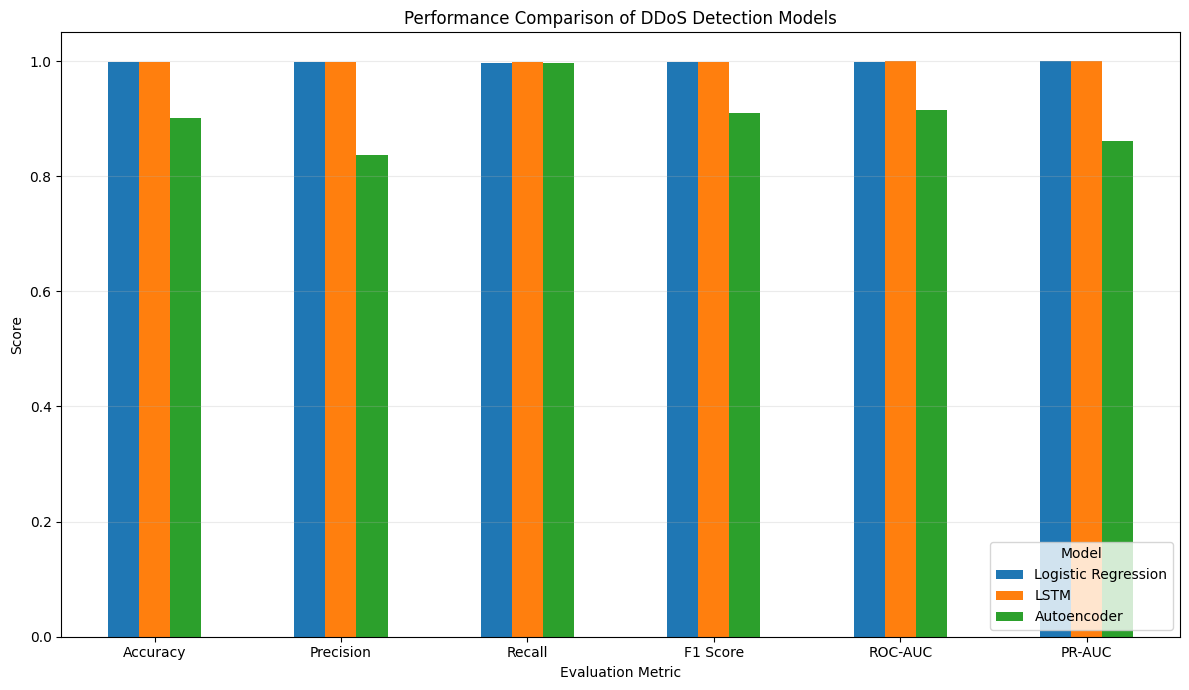

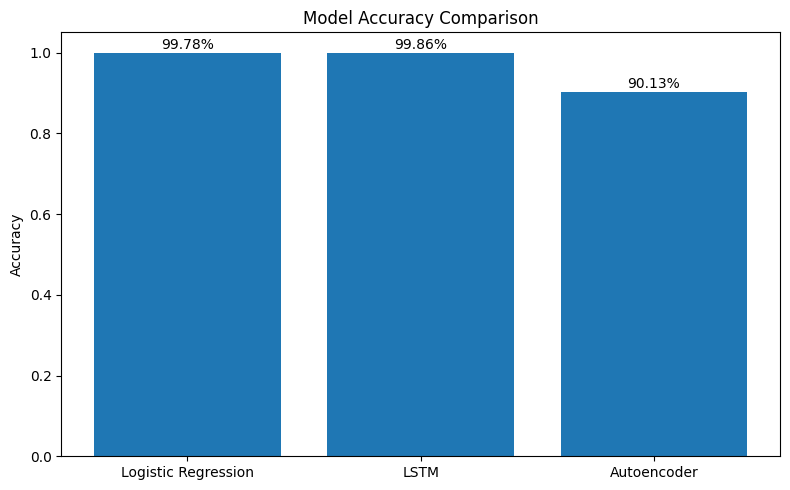

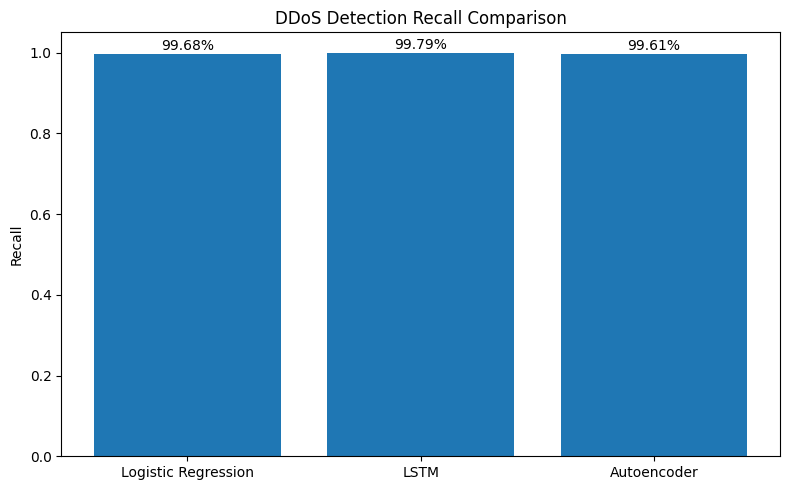


Autoencoder threshold saved: /content/drive/MyDrive/ML proj/DDoS_LSTM_Autoencoder_Project/backend/saved_models/autoencoder_threshold.json
Final metrics JSON saved: /content/drive/MyDrive/ML proj/DDoS_LSTM_Autoencoder_Project/results/final_metrics.json

PROJECT ML PIPELINE COMPLETE

Models saved in:
/content/drive/MyDrive/ML proj/DDoS_LSTM_Autoencoder_Project/backend/saved_models

Graphs saved in:
/content/drive/MyDrive/ML proj/DDoS_LSTM_Autoencoder_Project/results/graphs

Results saved in:
/content/drive/MyDrive/ML proj/DDoS_LSTM_Autoencoder_Project/results

Autoencoder threshold: 0.126525490859982

✅ LOGISTIC REGRESSION COMPLETE
✅ LSTM COMPLETE
✅ AUTOENCODER COMPLETE
✅ MODEL COMPARISON COMPLETE
✅ ALL MODEL RESULTS SAVED


In [17]:
# ============================================================
# 7. FINAL MODEL COMPARISON AND SAVE RESULTS
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import json


# ============================================================
# 1. LOCK FINAL AUTOENCODER RESULT
# ============================================================

# Use the validation-optimized threshold as the final threshold.
best_threshold = float(optimized_threshold)

# Replace previous Autoencoder metrics with optimized metrics.
ae_metrics = ae_metrics_optimized

# Replace previous Autoencoder predictions with optimized predictions.
ae_pred = ae_pred_optimized


print("=" * 60)
print("FINAL MODEL RESULTS")
print("=" * 60)

print("\nLogistic Regression:")
print(lr_metrics)

print("\nLSTM:")
print(lstm_metrics)

print("\nAutoencoder:")
print(ae_metrics)

print(
    "\nFinal Autoencoder Threshold:",
    best_threshold
)


# ============================================================
# 2. CREATE COMPARISON TABLE
# ============================================================

comparison_df = pd.DataFrame({

    "Model": [
        "Logistic Regression",
        "LSTM",
        "Autoencoder"
    ],

    "Accuracy": [
        lr_metrics["accuracy"],
        lstm_metrics["accuracy"],
        ae_metrics["accuracy"]
    ],

    "Precision": [
        lr_metrics["precision"],
        lstm_metrics["precision"],
        ae_metrics["precision"]
    ],

    "Recall": [
        lr_metrics["recall"],
        lstm_metrics["recall"],
        ae_metrics["recall"]
    ],

    "F1 Score": [
        lr_metrics["f1"],
        lstm_metrics["f1"],
        ae_metrics["f1"]
    ],

    "ROC-AUC": [
        lr_metrics["roc_auc"],
        lstm_metrics["roc_auc"],
        ae_metrics["roc_auc"]
    ],

    "PR-AUC": [
        lr_metrics["pr_auc"],
        lstm_metrics["pr_auc"],
        ae_metrics["pr_auc"]
    ]
})


print("\n" + "=" * 60)
print("MODEL COMPARISON")
print("=" * 60)

display(
    comparison_df.style.format({
        "Accuracy": "{:.4%}",
        "Precision": "{:.4%}",
        "Recall": "{:.4%}",
        "F1 Score": "{:.4%}",
        "ROC-AUC": "{:.4%}",
        "PR-AUC": "{:.4%}"
    })
)


# ============================================================
# 3. SAVE COMPARISON CSV
# ============================================================

metrics_path = (
    RESULTS_DIR /
    "model_comparison.csv"
)

comparison_df.to_csv(
    metrics_path,
    index=False
)

print(
    "\nComparison table saved:",
    metrics_path
)


# ============================================================
# 4. MODEL COMPARISON BAR GRAPH
# ============================================================

metrics_to_plot = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1 Score",
    "ROC-AUC",
    "PR-AUC"
]


plot_df = comparison_df.set_index(
    "Model"
)[metrics_to_plot]


ax = plot_df.T.plot(
    kind="bar",
    figsize=(12, 7)
)

plt.title(
    "Performance Comparison of DDoS Detection Models"
)

plt.ylabel(
    "Score"
)

plt.xlabel(
    "Evaluation Metric"
)

plt.ylim(
    0,
    1.05
)

plt.xticks(
    rotation=0
)

plt.legend(
    title="Model",
    loc="lower right"
)

plt.grid(
    axis="y",
    alpha=0.25
)

plt.tight_layout()

plt.savefig(
    GRAPH_DIR /
    "final_model_comparison.png",
    dpi=250,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# 5. ACCURACY COMPARISON GRAPH
# ============================================================

plt.figure(
    figsize=(8, 5)
)

plt.bar(
    comparison_df["Model"],
    comparison_df["Accuracy"]
)

plt.title(
    "Model Accuracy Comparison"
)

plt.ylabel(
    "Accuracy"
)

plt.ylim(
    0,
    1.05
)

for index, value in enumerate(
    comparison_df["Accuracy"]
):

    plt.text(
        index,
        value + 0.01,
        f"{value * 100:.2f}%",
        ha="center"
    )

plt.tight_layout()

plt.savefig(
    GRAPH_DIR /
    "model_accuracy_comparison.png",
    dpi=250,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# 6. RECALL COMPARISON
# Important for attack detection
# ============================================================

plt.figure(
    figsize=(8, 5)
)

plt.bar(
    comparison_df["Model"],
    comparison_df["Recall"]
)

plt.title(
    "DDoS Detection Recall Comparison"
)

plt.ylabel(
    "Recall"
)

plt.ylim(
    0,
    1.05
)

for index, value in enumerate(
    comparison_df["Recall"]
):

    plt.text(
        index,
        value + 0.01,
        f"{value * 100:.2f}%",
        ha="center"
    )

plt.tight_layout()

plt.savefig(
    GRAPH_DIR /
    "model_recall_comparison.png",
    dpi=250,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# 7. SAVE AUTOENCODER THRESHOLD
# Needed later by backend / website
# ============================================================

threshold_data = {
    "autoencoder_threshold":
        float(best_threshold),

    "validation_f1":
        float(optimized_val_f1),

    "selection_method":
        "Maximum F1 on validation precision-recall curve"
}


threshold_path = (
    MODEL_DIR /
    "autoencoder_threshold.json"
)


with open(
    threshold_path,
    "w"
) as file:

    json.dump(
        threshold_data,
        file,
        indent=4
    )


print(
    "\nAutoencoder threshold saved:",
    threshold_path
)


# ============================================================
# 8. SAVE ALL MODEL METRICS AS JSON
# ============================================================

all_results = {

    "Logistic Regression": {
        key: float(value)
        for key, value
        in lr_metrics.items()
    },

    "LSTM": {
        key: float(value)
        for key, value
        in lstm_metrics.items()
    },

    "Autoencoder": {
        key: float(value)
        for key, value
        in ae_metrics.items()
    }
}


results_json_path = (
    RESULTS_DIR /
    "final_metrics.json"
)


with open(
    results_json_path,
    "w"
) as file:

    json.dump(
        all_results,
        file,
        indent=4
    )


print(
    "Final metrics JSON saved:",
    results_json_path
)


# ============================================================
# 9. FINAL VERIFICATION
# ============================================================

print("\n" + "=" * 60)
print("PROJECT ML PIPELINE COMPLETE")
print("=" * 60)

print("\nModels saved in:")
print(MODEL_DIR)

print("\nGraphs saved in:")
print(GRAPH_DIR)

print("\nResults saved in:")
print(RESULTS_DIR)

print(
    "\nAutoencoder threshold:",
    best_threshold
)

print("\n✅ LOGISTIC REGRESSION COMPLETE")
print("✅ LSTM COMPLETE")
print("✅ AUTOENCODER COMPLETE")
print("✅ MODEL COMPARISON COMPLETE")
print("✅ ALL MODEL RESULTS SAVED")

In [18]:
# ============================================================
# SAVE DEPLOYMENT ARTIFACTS FOR WEBSITE/BACKEND
# ============================================================

import json
import joblib

# 1. Save scaler
SCALER_PATH = MODEL_DIR / "scaler.joblib"
joblib.dump(scaler, SCALER_PATH)

# 2. Save exact feature order
FEATURES_PATH = MODEL_DIR / "feature_columns.json"

with open(FEATURES_PATH, "w") as f:
    json.dump(
        feature_columns,
        f,
        indent=4
    )

# 3. Save model configuration
CONFIG_PATH = MODEL_DIR / "model_config.json"

model_config = {
    "project": "DDoS Attack Detection Using LSTM and Autoencoder",
    "dataset": "CICDDoS2019",
    "number_of_features": len(feature_columns),
    "lstm_sequence_length": 8,
    "binary_labels": {
        "0": "BENIGN",
        "1": "DDoS"
    },
    "autoencoder_threshold": float(best_threshold),
    "models": {
        "logistic_regression": "logistic_regression.joblib",
        "lstm": "lstm_model.keras",
        "autoencoder": "autoencoder_model.keras"
    }
}

with open(CONFIG_PATH, "w") as f:
    json.dump(
        model_config,
        f,
        indent=4
    )

print("=" * 60)
print("DEPLOYMENT ARTIFACTS SAVED")
print("=" * 60)

print("Scaler:", SCALER_PATH)
print("Features:", FEATURES_PATH)
print("Config:", CONFIG_PATH)

print("\nNumber of model features:", len(feature_columns))
print("LSTM sequence length: 8")
print("Autoencoder threshold:", best_threshold)

print("\n✅ BACKEND DEPLOYMENT FILES READY")

DEPLOYMENT ARTIFACTS SAVED
Scaler: /content/drive/MyDrive/ML proj/DDoS_LSTM_Autoencoder_Project/backend/saved_models/scaler.joblib
Features: /content/drive/MyDrive/ML proj/DDoS_LSTM_Autoencoder_Project/backend/saved_models/feature_columns.json
Config: /content/drive/MyDrive/ML proj/DDoS_LSTM_Autoencoder_Project/backend/saved_models/model_config.json

Number of model features: 68
LSTM sequence length: 8
Autoencoder threshold: 0.126525490859982

✅ BACKEND DEPLOYMENT FILES READY
